### American vs Euorpean Options
The key difference between American and European option lies in their boundary coditions.\
Black-Scholes European Option = PDE holds for: 0 $\leq$ $\tau$ $\leq$ T, S > 0 \
Black-Scholes American Option = PDE holds for: 0 $\leq$ $\tau$ $\leq$ T, 0 < S $\leq$ b($\nu$, $\tau$)

Where:\
T = Maturity\
$\tau$ = Time Remaining Until to Maturity\
$\nu$ = Volatility\
b($\nu$, $\tau$) = Critical threshold where if stok price crosses this boundary, the PDE no longer applies because it becomes mathematically optimal to exercise the option immediately rather than continue holding it.

### The Early Excercise Boundary

$C_A = C_E + V$

European Call Price: $C_E$\
Early Exercise Premium: $V$


Numerical Methods to Solve for this Free Boundary:\
- Binomial Trees
- Finit Differences
- Monte Carlo with Regression

When would early excercise become desireable?
1. dividends that the owner of the stock will recieve
2. positive cashflow on interest earned

In the case that there are not dividend/interest considerations, then the value of the american option should equal the value of a European option.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
# from IPython.display import disp

#notebook chart design 
plt.rcParams.update({
    "axes.facecolor": "#f9f9f9", "figure.facecolor": "white",
    "axes.grid": True, "grid.color": "#e0e0e0", "grid.linewidth": 0.7,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "xtick.labelsize": 8, "ytick.labelsize": 8, "font.family": "serif",
})
blue = "#2166ac"
red ="#d6604d"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets

# Black–Scholes European formulas
def bs_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def bs_put(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Binomial tree for American option
def american_binomial(S, K, r, sigma, T, N, opt_type="call"):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1/u
    p = (np.exp(r * dt) - d) / (u - d)

    # stock prices
    ST = np.array([S * u**j * d**(N-j) for j in range(N+1)])

    # terminal payoff
    if opt_type == "call":
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # backward induction
    for i in range(N-1, -1, -1):
        ST = ST[1:] / u  # step down tree
        V = np.exp(-r*dt)*(p*V[1:] + (1-p)*V[:-1])
        intrinsic = (ST - K) if opt_type == "call" else (K - ST)
        V = np.maximum(V, intrinsic)

    return V[0]

# Parameters 
S_range = np.linspace(50, 150, 100)
K = 100
sigma = 0.25
T = 1.0
N = 200

# Create interactive plot function 
def plot_options(q, r):
    # Compute option values
    euro_calls = [bs_call(s, K, r - q, sigma, T) for s in S_range]
    euro_puts = [bs_put(s, K, r - q, sigma, T) for s in S_range]
    
    amer_calls = [american_binomial(s, K, r - q, sigma, T, N, "call") for s in S_range]
    amer_puts = [american_binomial(s, K, r - q, sigma, T, N, "put") for s in S_range]
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # CALLS 
    ax = axes[0]
    ax.plot(S_range, euro_calls, 'k--', label="European Call", linewidth=2)
    ax.plot(S_range, amer_calls, 'b-', label="American Call", linewidth=2)
    ax.set_title("Call Options", fontsize=14, fontweight='bold')
    ax.set_xlabel("Underlying Price ($)", fontsize=12)
    ax.set_ylabel("Option Value ($)", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # PUTS
    ax = axes[1]
    ax.plot(S_range, euro_puts, 'k--', label="European Put", linewidth=2)
    ax.plot(S_range, amer_puts, 'b-', label="American Put", linewidth=2)
    ax.set_title("Put Options", fontsize=14, fontweight='bold')
    ax.set_xlabel("Underlying Price ($)", fontsize=12)
    ax.set_ylabel("Option Value ($)", fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Interactive American vs European Option Pricing\nContinuous Dividend Yield: {q:.1%} | Interest Rate: {r:.1%}', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Create interactive widgets
q_slider = widgets.FloatSlider(
    value=0.0,
    min=0.0,
    max=0.10,
    step=0.005,
    description='Dividend (q):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1%',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

r_slider = widgets.FloatSlider(
    value=0.02,
    min=-0.05,
    max=0.15,
    step=0.005,
    description='Interest Rate (r):',
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1%',
    style={'description_width': '120px'},
    layout=widgets.Layout(width='600px')
)

widgets.interact(plot_options, q=q_slider, r=r_slider)

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='Dividend (q):', layout=Layo…

<function __main__.plot_options(q, r)>

In theory, an American call on a non-dividend paying stock is equal to a European call. so the following conditions are when divergence becomes meaningful.
1. Intrinsic value is large (Deep ITM), and holding the call means missing out on dividend yield or holding onto the put meaning missing out on interest
2. High Dividend Yield (q), dividend stream is "carry cost" of holding stock via call.

Early exercise only matters when you gain more by taking the stock now than by keeping your optionality. Whether that's because of dividend considerations or possible interest earned.

### Scenarios
1. For American call options on non-dividend-paying stocks\
There is never a rational reason to exercise early.
2. For American call options on dividend-paying stocks\
Early exercise can be optimal right before an ex-dividend date.
3. For American put options\
Early exercise can many times be optimal.
 
Why Put Options:
- Deep-in-the-money puts behave like debt - by exercising early, you receive cash today rather than later.

- If interest rates are positive, receiving cash sooner can outweigh remaining time value.

- Deep-in-the-money + low volatility + longer maturity increases the chance that early exercise is optimal.

- There's no single "timestamp," but the early-exercise region is well-defined in models like the free-boundary solution of the American PDE.

## Synthetic Data Creation
- Synthetic data will allow us to create features that encompass every economically viable condition found in the market
- Each feature must have a different range, otherwise, the dataset will become over encoimpassing and too large for price generation.
- Since its impossible to combine every possible feature value with eachother sampling is important. We will create five matrices of values one for each feature and combine them to create the dataset.

#### Sampling
Without sampling when generating my dataset every possible increment of a value would need to be included. This is not possible, thus, we use sampling to generate thousands of these combinations automatically. The different methods listed determine whether these values are spread evenly, or are concentrated differently across values.

- **Uniform sampling:** Draws each value with equal probability acrosss the range of values. We use this for parameters who scale lineraly across the range and want none of the value to have more representation in the dataset over others.

- **Log-uniform sampling:** Draws each value with equal probability across log-space. We use this on features that change multiplicatly like volatility. Using something like **Uniform Sampling** would under represent low volatility values which are what is most typically found in regular market conditions.

#### Boundaries:
- **Moneyness (K/S): 0.50 to 1.50** covers deep ITM to deep OTM while excluding sub-0.50 territory where options behave like pure stock positions and add little training signal.

- **Time to Expiry (T): 0.005 to 3.0 years** uses 0.005 (~2 days) as the practical floor before binomial trees become numerically unstable, and 3.0 years captures LEAPS without wasting samples on the 3 to 5 year range where behavior barely changes.

- **Volatility (σ): 0.05 to 1.50** sets 0.05 to reflect the quietest liquid instruments and 1.50 to cover extreme events like biotech binary readouts or meme stocks, capturing the full spectrum of real-world vol regimes the model may encounter.

- **Risk-free rate (r): -0.02 to 0.10** sets -0.02 to reflect the negative rate environment seen in Europe and Japan post-2008, and 0.10 to cover aggressive tightening cycles like 2022 to 2023 without sampling rates that have never existed in modern developed markets.

- **Dividend yield (q): 0.00 to 0.06** spans from zero for growth stocks and non-payers up to 0.06 for the highest-yielding liquid equities with active options markets, ensuring adequate coverage of cases where q > r which triggers rational early exercise on American calls.




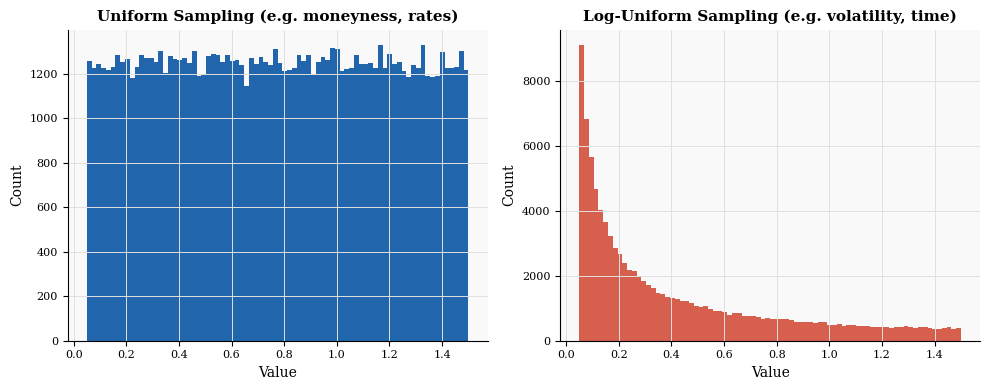

In [4]:

N = 100_000
lo, hi = 0.05, 1.50

uniform_samples = np.random.uniform(lo, hi, N)
log_uniform_samples = np.exp(np.random.uniform(np.log(lo), np.log(hi), N))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(uniform_samples, bins=80, color=blue, linewidth=0.4)
axes[0].set_title("Uniform Sampling (e.g. moneyness, rates)")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

axes[1].hist(log_uniform_samples, bins=80, color=red, linewidth=0.4)
axes[1].set_title("Log-Uniform Sampling (e.g. volatility, time)")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

def generateOptionsGrid(n_random=50000):

    mon_range= (0.50, 1.50)
    time_range= (0.005, 3.0)
    vol_range= (0.05, 1.50)
    rfr_range= (-0.02, 0.10)
    div_range= (0.00, 0.06)

    np.random.seed(42)
    N = n_random

    S = 100.0
    moneyness = np.random.uniform(*mon_range, N)

    data = pd.DataFrame({
        'S':np.full(N, S),
        'K':S * moneyness,
        'T':np.exp(np.random.uniform(np.log(time_range[0]), np.log(time_range[1]), N)),
        'r':np.random.uniform(*rfr_range, N),
        'sigma':np.exp(np.random.uniform(np.log(vol_range[0]), np.log(vol_range[1]), N)),
        'q':np.random.uniform(*div_range, N),
        'option_type': np.random.choice([1, 0], N)
    })

    # Systematic grid to guarantee coverage of key regimes
    moneyness_cases = []
    for m in [0.5, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.5]:
        for T in [1/52, 1/12, 0.25, 0.5, 1.0, 2.0]:
            for sigma in [0.1, 0.2, 0.4, 0.8]:
                for r in [0.01, 0.04, 0.07]:
                    moneyness_cases.append({
                        'S': S, 'K': S * m, 'T': T, 'r': r,
                        'sigma': sigma, 'q': 0.02,
                        'option_type': np.random.choice([1, 0])
                    })

    systematic = pd.DataFrame(moneyness_cases)
    df = pd.concat([data, systematic], ignore_index=True)

    return df.reset_index(drop=True)

In [6]:
df = generateOptionsGrid(500000)
df.head(20)

,S,K,T,r,sigma,q,option_type
0,100.0,87.454012,0.033880,0.051419,0.576443,0.006109,0
1,100.0,145.071431,0.130146,0.023766,0.211709,0.017897,1
2,100.0,123.199394,0.307565,-0.019355,0.099072,0.038194,1
3,100.0,109.865848,2.853534,0.047331,0.069293,0.026140,1
4,100.0,65.601864,0.427395,0.087588,0.531824,0.013235,1
5,100.0,65.599452,0.106844,0.043806,0.712437,0.059448,0
6,100.0,55.808361,0.066008,0.073659,0.403205,0.039253,0
7,100.0,136.617615,0.035235,-0.000565,1.273938,0.049212,0
8,100.0,110.111501,0.015287,-0.003524,0.082065,0.054284,1
9,100.0,120.807258,0.033761,0.087273,0.137376,0.008267,0


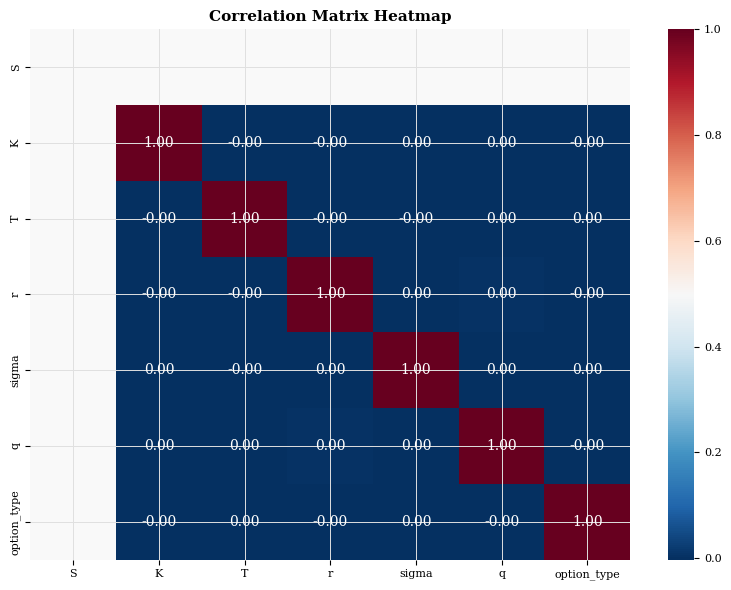

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

This signals that none of the features are correlated, which we were hoping to accompkish with this data.

## Lets Compare the Synthetic Data to SPY Options Chain

In [8]:
data = pd.read_csv('spy.csv')
data.head()


/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/2132792864.py:1: DtypeWarning: Columns (8,9,10,11,12,13,15,17,18,20,21,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('spy.csv')


,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,...,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [9]:
pd.set_option('display.max_columns', None)
data.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005170,,1.000000,182.650000,1 x 1,181.090000,182.310000,270.0,0.000000,0.010000,0 x 2239,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005270,,,0.000000,1 x 1,176.090000,177.310000,275.0,0.000000,0.010000,0 x 2679,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005690,,25.000000,157.750000,1 x 1,171.090000,172.310000,280.0,0.000000,0.010000,0 x 2679,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005300,,25.000000,153.450000,1 x 1,166.140000,167.300000,285.0,0.000000,0.010000,0 x 2679,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005340,,25.000000,147.760000,1 x 1,161.090000,162.310000,290.0,0.000000,0.010000,0 x 2679,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [10]:
data.describe()

,[QUOTE_UNIXTIME],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_UNIX],[DTE],[STRIKE],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
count,3.589079e+06,3589079.0,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06,3.589079e+06
mean,1.625102e+09,16.0,3.867732e+02,1.638526e+09,1.553685e+02,3.673370e+02,6.990646e+01,1.822063e-01
std,2.662208e+07,0.0,5.610069e+01,3.118598e+07,2.022561e+02,1.084168e+02,6.846897e+01,1.743915e-01
min,1.577999e+09,16.0,2.222100e+02,1.578085e+09,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00
25%,1.602187e+09,16.0,3.426500e+02,1.613768e+09,1.900000e+01,3.000000e+02,2.140000e+01,5.600000e-02
50%,1.625688e+09,16.0,3.934800e+02,1.639775e+09,6.404000e+01,3.680000e+02,4.760000e+01,1.250000e-01
75%,1.647461e+09,16.0,4.341600e+02,1.660939e+09,2.200400e+02,4.350000e+02,9.970000e+01,2.630000e-01
max,1.672434e+09,16.0,4.777700e+02,1.766178e+09,1.096000e+03,4.898000e+03,4.469300e+03,1.042500e+01


In [11]:
print(data.columns.tolist())

['[QUOTE_UNIXTIME]', ' [QUOTE_READTIME]', ' [QUOTE_DATE]', ' [QUOTE_TIME_HOURS]', ' [UNDERLYING_LAST]', ' [EXPIRE_DATE]', ' [EXPIRE_UNIX]', ' [DTE]', ' [C_DELTA]', ' [C_GAMMA]', ' [C_VEGA]', ' [C_THETA]', ' [C_RHO]', ' [C_IV]', ' [C_VOLUME]', ' [C_LAST]', ' [C_SIZE]', ' [C_BID]', ' [C_ASK]', ' [STRIKE]', ' [P_BID]', ' [P_ASK]', ' [P_SIZE]', ' [P_LAST]', ' [P_DELTA]', ' [P_GAMMA]', ' [P_VEGA]', ' [P_THETA]', ' [P_RHO]', ' [P_IV]', ' [P_VOLUME]', ' [STRIKE_DISTANCE]', ' [STRIKE_DISTANCE_PCT]']


In [12]:
data.columns = data.columns.str.strip().str.replace('[', '', regex=False).str.replace(']', '', regex=False)

data["DTE"] = pd.to_numeric(data["DTE"], errors="coerce")
data["STRIKE"] = pd.to_numeric(data["STRIKE"], errors="coerce")
data["UNDERLYING_LAST"] = pd.to_numeric(data["UNDERLYING_LAST"], errors="coerce")
data["C_IV"] = pd.to_numeric(data["C_IV"], errors="coerce")

data["DTE_YEARS"] = data["DTE"] / 365
data["MONEYNESS"] = data["STRIKE"] / data["UNDERLYING_LAST"]

data = data[
    (data["UNDERLYING_LAST"] > 0) &
    (data["STRIKE"] > 0) &
    (data["DTE"] > 0) &
    (data["DTE"] < 3650) &
    (data["C_IV"] > 0) &
    (data["C_IV"] < 3) &
    (data["MONEYNESS"] > 0) &
    (data["MONEYNESS"] < 3)
]

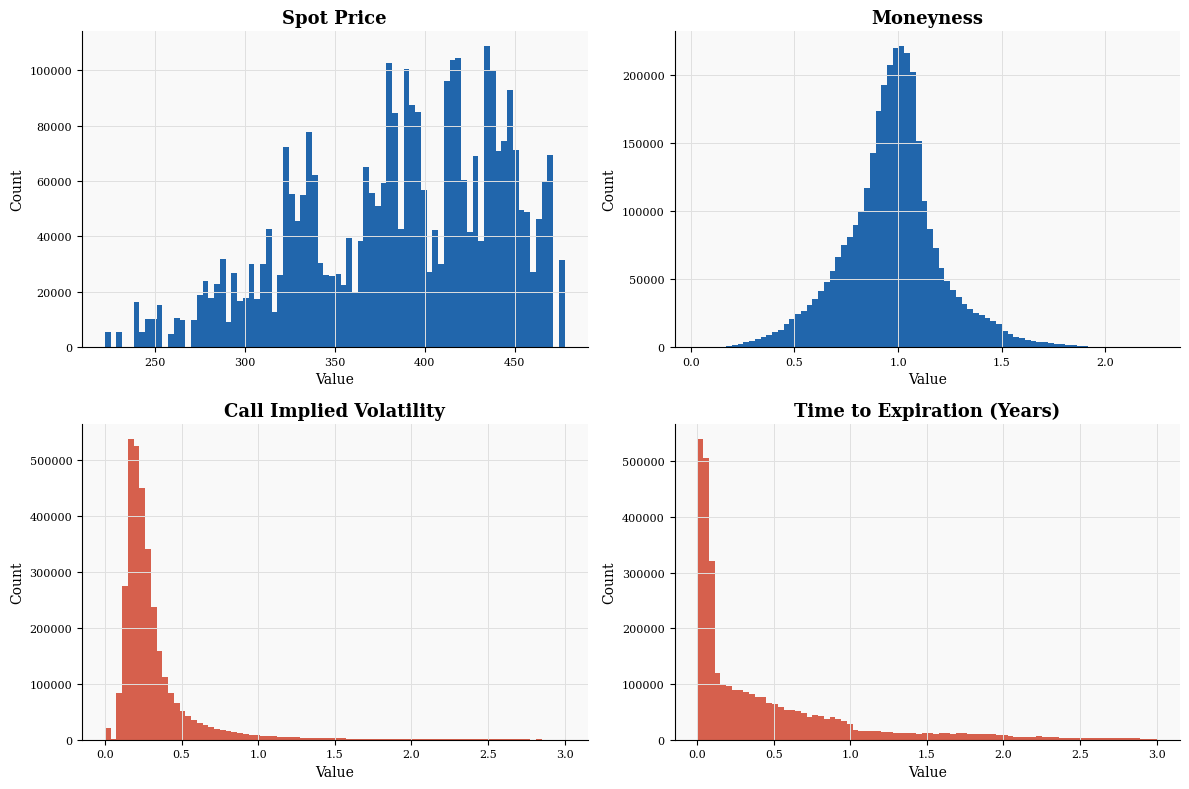

In [13]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0][0].hist(data["UNDERLYING_LAST"].dropna(), bins=80, color=blue, edgecolor="none")
axes[0][0].set_title("Spot Price", fontsize=13)
axes[0][0].set_xlabel("Value")
axes[0][0].set_ylabel("Count")

axes[0][1].hist(data["MONEYNESS"].dropna(), bins=80, color=blue, edgecolor="none")
axes[0][1].set_title("Moneyness", fontsize=13)
axes[0][1].set_xlabel("Value")
axes[0][1].set_ylabel("Count")

axes[1][0].hist(data["C_IV"].dropna(), bins=80, color=red, edgecolor="none")
axes[1][0].set_title("Call Implied Volatility", fontsize=13)
axes[1][0].set_xlabel("Value")
axes[1][0].set_ylabel("Count")

axes[1][1].hist(data["DTE_YEARS"].dropna(), bins=80, color=red, edgecolor="none")
axes[1][1].set_title("Time to Expiration (Years)", fontsize=13)
axes[1][1].set_xlabel("Value")
axes[1][1].set_ylabel("Count")



plt.tight_layout()
plt.show()

## Spot Price Distribution
This histogram shows the distribution of underlying asset prices in the real option chain dataset. The data spans a wide range of prices, reflecting the many different market conditions under which options are traded. Understanding the range of underlying prices helps ensure that the synthetic dataset used for model training reflects realistic market scenarios.

## Moneyness Distribution 
This plot shows the distribution of option moneyness, defined as strike price divided by the underlying asset price. The distribution peaks near 1.0, indicating that most traded options are close to at the money, while fewer options exist far in or out of the money.

## Call Implied Volatilty Distribution 
This histogram shows the distribution of implied volatility for call options. Most observations fall in the lower volatility range, with a long tail of higher volatility values representing periods of increased uncertainty or extreme market conditions.

## Time to Expiration 
This histogram shows the distribution of time to expiration in years. Most options have relatively short maturities, while fewer contracts extend to longer expiration horizons.

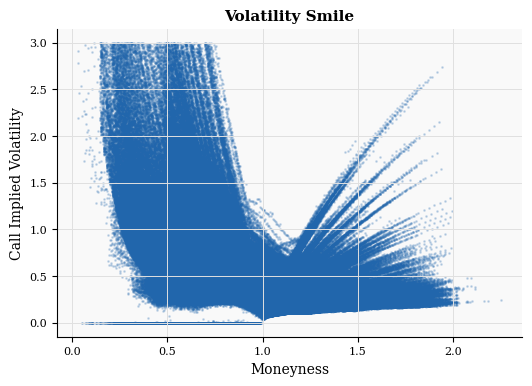

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(data["MONEYNESS"], data["C_IV"], s=1, alpha=0.2, color= blue)
plt.xlabel("Moneyness")
plt.ylabel("Call Implied Volatility")
plt.title("Volatility Smile")
plt.show()

## Volatility Smile
This scatter plot shows the relationship between moneyness and implied volatility. The curved shape illustrates the well-known volatility smile, where implied volatility tends to be higher for deep in-the-money and out-of-the-money options compared to at-the-money options

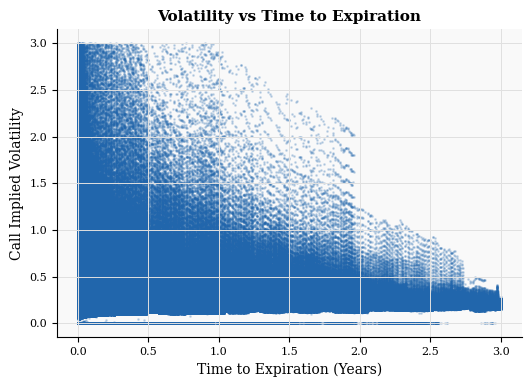

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(data["DTE_YEARS"], data["C_IV"], s=1, alpha=0.2, color= blue)
plt.xlabel("Time to Expiration (Years)")
plt.ylabel("Call Implied Volatility")
plt.title("Volatility vs Time to Expiration")
plt.show()

## Volatility vs Time to Expiration
This plot shows how implied volatility varies across different times to expiration. Shorter maturities tend to exhibit greater volatility dispersion, while longer maturities show more stable volatility levels.

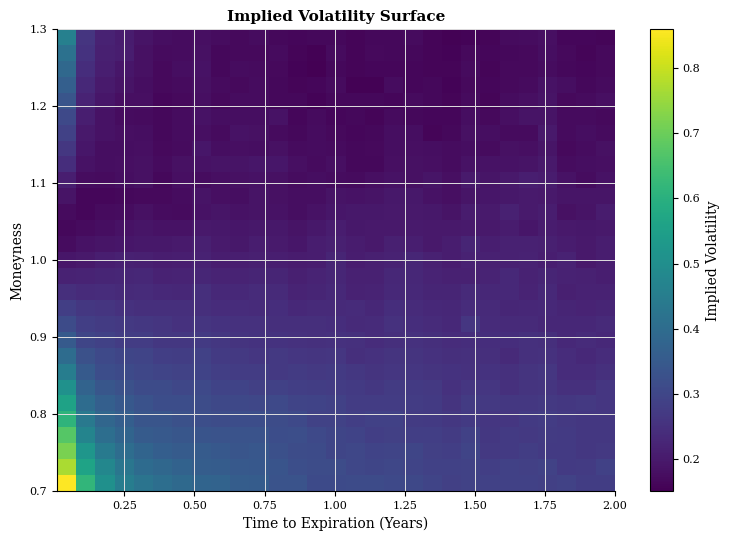

In [16]:
sample = data.sample(200000, random_state=42).copy()

moneyness_bins = np.linspace(0.7, 1.3, 30)
time_bins = np.linspace(0.01, 2.0, 30)

sample["m_bin"] = pd.cut(sample["MONEYNESS"], moneyness_bins)
sample["t_bin"] = pd.cut(sample["DTE_YEARS"], time_bins)

surface = sample.groupby(["m_bin","t_bin"], observed=False)["C_IV"].mean().unstack()

plt.figure(figsize=(9,6))

plt.imshow(
    surface.values,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[time_bins[0], time_bins[-1], moneyness_bins[0], moneyness_bins[-1]]
)

plt.colorbar(label="Implied Volatility")

plt.xlabel("Time to Expiration (Years)")
plt.ylabel("Moneyness")
plt.title("Implied Volatility Surface")

plt.show()

## Implied Volatility Surface Heatmap
This heatmap visualizes the implied volatility surface across both moneyness and time to expiration. The color intensity represents average implied volatility at each region of the surface, revealing how volatility changes across strike levels and maturities

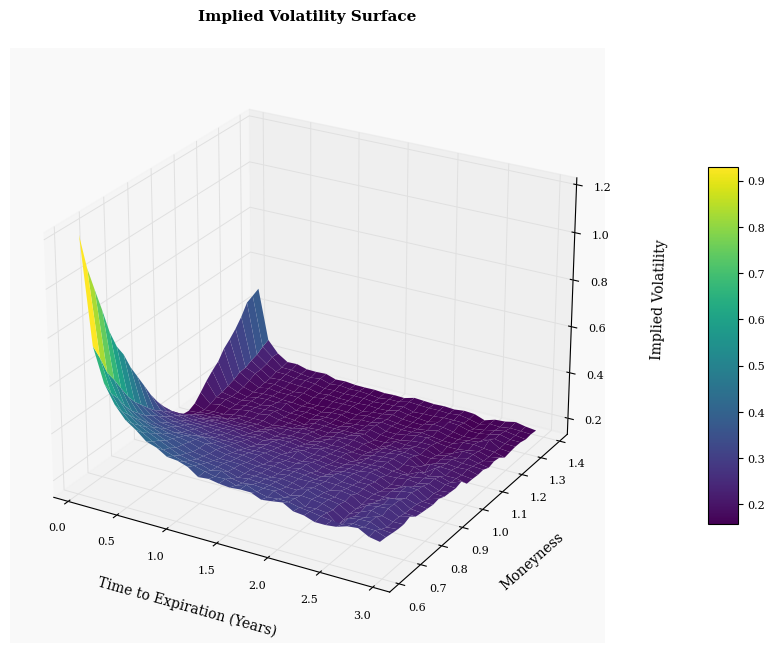

In [17]:
from mpl_toolkits.mplot3d import Axes3D

sample = data.sample(200000, random_state=42).copy()

moneyness_bins = np.linspace(0.6, 1.4, 30)
time_bins = np.linspace(0.01, 3, 30)

sample["m_bin"] = pd.cut(sample["MONEYNESS"], moneyness_bins)
sample["t_bin"] = pd.cut(sample["DTE_YEARS"], time_bins)

surface = sample.groupby(["m_bin", "t_bin"], observed=False)["C_IV"].mean().unstack()

X = np.array([b.mid for b in surface.columns])
Y = np.array([b.mid for b in surface.index])
X, Y = np.meshgrid(X, Y)
Z = surface.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)

ax.set_xlabel("Time to Expiration (Years)", labelpad=12)
ax.set_ylabel("Moneyness", labelpad=12)
ax.set_zlabel("Implied Volatility", labelpad=18)

ax.set_title("Implied Volatility Surface", pad=20)

ax.view_init(elev=25,azim=-60)

fig.colorbar(surf, shrink=0.6, aspect=12, pad=0.12)

plt.subplots_adjust(left=0.02,right=0.88,top=0.90, bottom=0.05)
plt.show()

## Revision of Synthetic Price Generation

### New synthetic data set
- improve spot range to random sample values from 80 - 120
- improve call/put logic it now creates a dataset for calls and one for puts then merges them together

In [18]:
def generateOptionsGrid(n_random=50000):
    spot_range = (80,120)
    mon_range= (0.50, 1.50)
    time_range= (0.005, 3.0)
    vol_range= (0.05, 1.50)
    rfr_range= (-0.02, 0.10)
    div_range= (0.00, 0.06)

    np.random.seed(42)
    N = n_random

    S = 100.0
    moneyness = np.random.uniform(*mon_range, N)

    data = pd.DataFrame({
        'S':np.random.uniform(spot_range[0], spot_range[1], N),
        'K':S * moneyness,
        'T':np.exp(np.random.uniform(np.log(time_range[0]), np.log(time_range[1]), N)),
        'r':np.random.uniform(*rfr_range, N),
        'sigma':np.exp(np.random.uniform(np.log(vol_range[0]), np.log(vol_range[1]), N)),
        'q':np.random.uniform(*div_range, N),
    })
    
    calls = data.assign(option_type=1)
    puts  = data.assign(option_type=0)
    data  = pd.concat([calls, puts], ignore_index=True)
    # Systematic grid to guarantee coverage of key regimes
    moneyness_cases = []
    for m in [0.5, 0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.5]:
        for T in [1/52, 1/12, 0.25, 0.5, 1.0, 2.0]:
            for sigma in [0.1, 0.2, 0.4, 0.8]:
                for r in [0.01, 0.04, 0.07]:
                    moneyness_cases.append({
                        'S': S, 'K': S * m, 'T': T, 'r': r,
                        'sigma': sigma, 'q': 0.02,
                        'option_type': np.random.choice([1, 0])
                    })

    systematic = pd.DataFrame(moneyness_cases)
    df = pd.concat([data, systematic], ignore_index=True)

    return df.reset_index(drop=True)

In [19]:
df = generateOptionsGrid()
df.head(5)


,S,K,T,r,sigma,q,option_type
0,113.889463,87.454012,0.205335,-0.011695,0.130733,0.056261,1
1,99.780682,145.071431,0.145538,0.050284,0.237953,0.004397,1
2,87.818624,123.199394,0.047228,0.075864,0.070069,0.011183,1
3,109.465671,109.865848,0.117271,0.071737,0.228561,0.038968,1
4,96.747125,65.601864,0.051673,0.080488,0.099758,0.026083,1


In [20]:
df.describe()

,S,K,T,r,sigma,q,option_type
count,100720.000000,100720.000000,100720.000000,100720.000000,100720.000000,1.007200e+05,100720.000000
mean,100.004492,99.865707,0.473467,0.040103,0.427243,2.998682e-02,0.499891
std,11.489774,28.823448,0.698524,0.034550,0.386928,1.725207e-02,0.500002
min,80.000337,50.000000,0.005001,-0.019999,0.050000,5.095760e-07,0.000000
25%,90.069338,74.940586,0.024900,0.010060,0.116458,1.525865e-02,0.000000
50%,100.000000,99.889191,0.125965,0.040000,0.273717,2.990733e-02,0.000000
75%,109.965189,124.729433,0.617102,0.069901,0.641907,4.492523e-02,1.000000
max,119.999682,150.000000,2.999796,0.099998,1.499894,5.999465e-02,1.000000


### Method to generate random sample options grid

In [21]:
import numpy as np
import pandas as pd
import QuantLib as ql
from math import ceil

import numpy as np
import pandas as pd

def generateOptionsGrid(n_random=50000):
    spot_range = (80, 120)
    time_range = (0.005, 3.0)
    vol_range = (0.05, 1.50)
    rfr_range = (-0.02, 0.10)
    div_range = (0.00, 0.06)

    np.random.seed(42)

    S_val = 100.0

    # 55% broadly sampled,  25% near expiriation, 20% near at the money 
    broad = int(n_random * 0.55)
    near_exp = int(n_random * 0.25)
    near_ATM = n_random - broad - near_exp

    # Broad Random Sampling
    S_broad = np.random.uniform(spot_range[0], spot_range[1], broad)
    m_broad = np.exp(np.random.uniform(np.log(0.50), np.log(1.50), broad))
    data_broad = pd.DataFrame({
        'S': S_broad,
        'K': S_broad * m_broad,
        'T': np.exp(np.random.uniform(np.log(time_range[0]), np.log(time_range[1]), broad)),
        'r': np.random.uniform(*rfr_range, broad),
        'sigma': np.exp(np.random.uniform(np.log(vol_range[0]), np.log(vol_range[1]), broad)),
        'q': np.random.uniform(*div_range, broad),

    })

    #near expiration options across the full moneyness range
    S_exp = np.random.uniform(85, 115, near_exp)
    m_exp = np.exp(np.random.uniform(np.log(0.80), np.log(1.20), near_exp))
    data_hard = pd.DataFrame({
        'S': S_exp,
        'K': S_exp * m_exp,
        'T': np.exp(np.random.uniform(np.log(0.003), np.log(0.10), near_exp)),
        'r': np.random.uniform(*rfr_range, near_exp),
        'sigma': np.exp(np.random.uniform(np.log(0.05), np.log(0.60), near_exp)),
        'q': np.random.uniform(*div_range, near_exp),
    })

    # Near at the money block
    S_near = np.random.uniform(spot_range[0], spot_range[1], near_ATM)
    m_near = np.exp(np.random.normal(0, 0.05, near_ATM))
    m_near = np.clip(m_near, 0.70, 1.30)
    data_atm = pd.DataFrame({
        'S': S_near,
        'K': S_near * m_near,
        'T': np.exp(np.random.uniform(np.log(time_range[0]), np.log(time_range[1]), near_ATM)),
        'r': np.random.uniform(*rfr_range, near_ATM),
        'sigma': np.exp(np.random.uniform(np.log(0.05), np.log(0.80), near_ATM)),
        'q': np.random.uniform(*div_range, near_ATM),
    })

    data = pd.concat([data_broad, data_hard, data_atm], ignore_index=True)

    # K realistic range
    data['K'] = data['K'].clip(lower=5.0)
    data['log_moneyness'] = np.log(data['S'] / data['K'])
    data['sqrt_T'] = np.sqrt(data['T'])

    calls = data.assign(option_type=1)
    puts= data.assign(option_type=0)
    data= pd.concat([calls, puts], ignore_index=True)

    # both calls and puts for each parameter combo
    moneyness_cases = []
    for m in [0.5, 0.7, 0.8, 0.85, 0.90, 0.95, 0.98, 1.0, 1.02, 1.05, 1.10, 1.15, 1.2, 1.5]:
        for T in [1/252, 3/252, 1/52, 1/12, 0.25, 0.5, 1.0, 2.0]:
            for sigma in [0.05, 0.10, 0.20, 0.35, 0.50, 0.80, 1.20]:
                for r in [0.00, 0.02, 0.05, 0.08]:
                    for opt_type in [1, 0]:
                        moneyness_cases.append({
                            'S': S_val, 'K': S_val * m, 'T': T, 'r': r,
                            'sigma': sigma, 'q': 0.02,
                            'option_type': opt_type,
                            'log_moneyness': np.log(1.0 / m),
                            'sqrt_T': np.sqrt(T),
                        })

    systematic = pd.DataFrame(moneyness_cases)
    df = pd.concat([data, systematic], ignore_index=True)
    
    return df.reset_index(drop=True)

In [22]:
df = generateOptionsGrid()
df.head(5)

,S,K,T,r,sigma,q,log_moneyness,sqrt_T,option_type
0,94.981605,138.154645,0.008803,0.036158,0.057020,0.037219,-0.374690,0.093822,1
1,118.028572,69.000309,0.005482,-0.002185,0.072419,0.002106,0.536816,0.074038,1
2,109.279758,145.460445,0.548624,0.056553,0.217681,0.003544,-0.285993,0.740692,1
3,103.946339,74.578482,0.026670,0.080711,1.249259,0.024876,0.332023,0.163310,1
4,86.240746,43.724145,1.371807,0.003343,0.064503,0.041627,0.679242,1.171242,1


### Method to add price column

In [23]:
import QuantLib as ql
def price_american_crr(S, K, T, r, sigma, q, option_type, steps=200):
    today = ql.Date.todaysDate()
    ql.Settings.instance().evaluationDate = today

    maturity = today + max(1, int(ceil(T * 365)))

    payoff_type = ql.Option.Call if int(option_type) == 1 else ql.Option.Put

    exercise = ql.AmericanExercise(today, maturity)
    payoff = ql.PlainVanillaPayoff(payoff_type, float(K))
    option = ql.VanillaOption(payoff, exercise)

    spot = ql.QuoteHandle(ql.SimpleQuote(float(S)))
    dividend_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(today, float(q), ql.Actual365Fixed())
    )
    riskfree_ts = ql.YieldTermStructureHandle(
        ql.FlatForward(today, float(r), ql.Actual365Fixed())
    )
    vol_ts = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(today, ql.NullCalendar(), float(sigma), ql.Actual365Fixed())
    )

    process = ql.BlackScholesMertonProcess(spot, dividend_ts, riskfree_ts, vol_ts)
    engine = ql.FdBlackScholesVanillaEngine(process, 200, 400)  #Switched to finite difference method industry standard when also considering hedging delta and gamma
    option.setPricingEngine(engine)

    return option.NPV()




### Method that calculates black scholes columns 

In [70]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def add_black_scholes_features(df):
    S, K, T, r, sigma, q = df['S'], df['K'], df['T'], df['r'], df['sigma'], df['q']
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    nd1 = norm.cdf(d1)
    nd2 = norm.cdf(d2)    
    call_price = S * np.exp(-q * T) * nd1 - K * np.exp(-r * T) * nd2
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    
    df['bs_price'] = np.where(df['option_type'] == 1, call_price, put_price)
    
    # Adding Delta for extra structural hints to the DNN
    call_delta = np.exp(-q * T) * nd1
    put_delta = -np.exp(-q * T) * norm.cdf(-d1)
    df['bs_delta'] = np.where(df['option_type'] == 1, call_delta, put_delta)
    
    return df



### Calculate Early excercise premium from American and European prices and add higher order greeks

In [71]:
def prepare_dnn_dataset(df):
    df = df.copy()
    df['moneyness'] = df['S'] / df['K']

    df['intrinsic_value_raw'] = np.where(
        df['option_type'] == 1, 
        np.maximum(df['S'] - df['K'], 0),  # Call
        np.maximum(df['K'] - df['S'], 0)   # Put
    )
    df['intrinsic_normalized'] = df['intrinsic_value_raw'] / df['K']

    df['total_variance'] = (df['sigma'] ** 2) * df['T']
    df['vol_sqrt_T'] = df['sigma'] * np.sqrt(df['T'])

    # Cost of Carry
    df['cost_of_carry'] = df['r'] - df['q']
    
    # Early Exercise Premium 
    df['EEP'] = df['american_price'] - df['bs_price']
    
    # Scale everything by Strike price
    df['norm_price'] = df['american_price'] / df['K']
    df['norm_bs_price'] = df['bs_price'] / df['K']
    df['norm_EEP'] = df['EEP'] / df['K']  # Target
    
    
    df['moneyness'] = df['S'] / df['K']
    df['time_scaled_variance'] = (df['sigma'] ** 2) * df['T']
    df['cost_of_carry'] = df['r'] - df['q']
    
    # Calculate Intrinsic Value
    intrin= np.where(
        df['option_type'] == 1, 
        np.maximum(df['S']- df['K'], 0), 
        np.maximum(df['K'] - df['S'], 0)
    )
    df['normalized_intrinsic'] = intrin / df['K']

    # Advanced Greeks Calculations
    d1 = (np.log(df['S'] / df['K']) + (df['r'] - df['q'] + 0.5 * df['sigma']**2) * df['T']) / (df['sigma'] * np.sqrt(df['T']))
    d2 = d1 - df['sigma'] * np.sqrt(df['T'])
    
    df['bs_gamma'] = (norm.pdf(d1) * np.exp(-df['q'] *df['T'])) / (df['S'] * df['sigma'] * np.sqrt(df['T']))
    df['bs_vega'] = (df['S'] * np.exp(-df['q'] *df['T']) * norm.pdf(d1) * np.sqrt(df['T'])) / 100.0
    theta_call = (- (df['S'] * df['sigma'] * np.exp(-df['q'] * df['T']) * norm.pdf(d1)) / (2 * np.sqrt(df['T'])) 
                  - df['r'] * df['K'] * np.exp(-df['r'] * df['T']) * norm.cdf(d2) 
                  + df['q'] * df['S'] * np.exp(-df['q'] * df['T']) * norm.cdf(d1)) / 365.0
                  
    theta_put = (- (df['S'] * df['sigma'] * np.exp(-df['q'] * df['T']) * norm.pdf(d1)) / (2 * np.sqrt(df['T'])) 
                 + df['r'] * df['K'] * np.exp(-df['r'] * df['T']) * norm.cdf(-d2) 
                 - df['q'] * df['S'] * np.exp(-df['q'] * df['T']) * norm.cdf(-d1)) / 365.0
    
    df['bs_theta'] = np.where(df['option_type'] == 1, theta_call, theta_put)

    df['strike_distance_pct'] = (df['K'] - df['S']) / df['S']
    return df
    
    print("Dataset preparation complete.")
    return df

In [72]:
df.head()

,S,K,T,r,sigma,q,log_moneyness,sqrt_T,option_type,bs_price,bs_delta,american_price,moneyness,intrinsic_value_raw,intrinsic_normalized,total_variance,vol_sqrt_T,cost_of_carry,EEP,norm_price,norm_bs_price,norm_EEP,time_scaled_variance,normalized_intrinsic,bs_gamma,bs_vega,bs_theta,strike_distance_pct
0,94.981605,138.154645,0.008803,0.036158,0.057020,0.037219,-0.374690,0.093822,1,0.000000,0.000000,0.000000,0.687502,0.000000,0.000000,0.000029,0.005350,-0.001061,0.000000,0.000000,0.000000,0.000000,0.000029,0.000000,0.000000e+00,0.000000e+00,0.000000,0.454541
1,118.028572,69.000309,0.005482,-0.002185,0.072419,0.002106,0.536816,0.074038,1,49.026075,0.999988,49.028264,1.710551,49.028264,0.710551,0.000029,0.005362,-0.004290,0.002189,0.710551,0.710520,0.000032,0.000029,0.710551,0.000000e+00,0.000000e+00,0.001094,-0.415393
2,109.279758,145.460445,0.548624,0.056553,0.217681,0.003544,-0.285993,0.740692,1,0.470891,0.046972,0.475868,0.751268,0.000000,0.000000,0.025996,0.161234,0.053009,0.004977,0.003271,0.003237,0.000034,0.025996,0.000000,7.196515e-03,1.026352e-01,-0.006538,0.331083
3,103.946339,74.578482,0.026670,0.080711,1.249259,0.024876,0.332023,0.163310,1,29.841740,0.936707,29.871184,1.393785,29.367857,0.393785,0.041623,0.204016,0.055834,0.029445,0.400534,0.400139,0.000395,0.041623,0.393785,4.160768e-03,1.497849e-02,-0.104748,-0.282529
4,86.240746,43.724145,1.371807,0.003343,0.064503,0.041627,0.679242,1.171242,1,37.929901,0.944495,42.516601,1.972383,42.516601,0.972383,0.005708,0.075549,-0.038284,4.586700,0.972383,0.867482,0.104901,0.005708,0.972383,4.810629e-17,3.165917e-16,0.008891,-0.492999


### DNN Initialization

In [103]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

class surrogateDNN(nn.Module):
    def __init__(self, input_size, output_size):
        super(surrogateDNN, self).__init__() 
        self.net = nn.Sequential(
            nn.Linear(input_size, 400),
            nn.SiLU(), 
            nn.Linear(400, 400),
            nn.SiLU(),
            nn.Linear(400, 400),
            nn.SiLU(),
            nn.Linear(400, 400),
            nn.SiLU(),
            nn.Linear(400, 400),
            nn.SiLU(),
            nn.Linear(400, 400),
            nn.SiLU(),
            nn.Linear(400, output_size)
        )

    def forward(self, x):
        return self.net(x)

# Method for preparing data for training
def prepare_data(df, target_col, batch_size=256): 
    # drop intermediate price columns to prevent data leakage
    cols_to_drop = cols_to_drop = [target_col, 'american_price', 'bs_price', 'EEP', 'norm_price', 'S', 'K', 'intrinsic_value_raw']
    X = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    y = df[target_col].values.reshape(-1, 1) 

    indices = np.arange(len(df))
    
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, indices, test_size=0.2, random_state=42
    )

    # the raw Strike (K) and BS Price specifically for the test set evaluation later and for descaling    
    K_test = df['K'].values[idx_test].reshape(-1, 1)
    bs_price_test = df['bs_price'].values[idx_test].reshape(-1, 1)
    option_type_test = df['option_type'].values[idx_test].reshape(-1, 1) #extract option type for mertons rule
    q_test = df['q'].values[idx_test].reshape(-1, 1) #extract dividend for mertons rule

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test) 

    # Scale Targets
    y_scaler = StandardScaler()
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # Convert to Tensors
    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32) 
    y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

    # Create Loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


    return train_loader, test_loader, X.shape[1], y_scaler, x_scaler, K_test, bs_price_test, option_type_test, q_test


        

In [104]:
a=pd.read_csv("spy.csv", nrows= 100)
a.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.0,0.0,0.0,0.0,0.00517,,1.000000,182.65,1 x 1,181.09,182.31,270.0,0.0,0.01,0 x 2239,0.01,-0.00024,0.00000,0.00004,-0.00509,0.0,3.41249,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.0,0.0,0.0,0.0,0.00527,,,0.00,1 x 1,176.09,177.31,275.0,0.0,0.01,0 x 2679,0.01,-0.00063,0.00003,0.00019,-0.00480,0.0,3.29737,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.0,0.0,0.0,0.0,0.00569,,25.000000,157.75,1 x 1,171.09,172.31,280.0,0.0,0.01,0 x 2679,0.01,0.00000,0.00000,-0.00023,-0.00534,0.0,3.18330,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.0,0.0,0.0,0.0,0.00530,,25.000000,153.45,1 x 1,166.14,167.30,285.0,0.0,0.01,0 x 2679,0.01,-0.00016,0.00004,0.00038,-0.00532,0.0,3.07217,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.0,0.0,0.0,0.0,0.00534,,25.000000,147.76,1 x 1,161.09,162.31,290.0,0.0,0.01,0 x 2679,0.01,-0.00068,0.00000,0.00045,-0.00515,0.0,2.96230,0.000000,161.9,0.358


## Now that we built a mathematically exceptional model we need to tweak it to perform well in actual market conditions
#### Higher Order Greeks
- Gamma tells the network how fast Delta is changing (the curvature of the price surface).

- Theta tells the network how heavily the option is decaying (critical for the Early Exercise Premium, as time value is the barrier to early exercise).

- Vega tells the network how sensitive the premium is to the Volatility input.

#### Volatility Surface
- While your network sees the IV, feeding it the explicit [STRIKE_DISTANCE_PCT] gives it spatial awareness of where this option sits on the volatility smile.

In [105]:
print("Generating parameter")
raw_grid_df = generateOptionsGrid(n_random=50000)
price_df = add_black_scholes_features(raw_grid_df)
print("Pricing")
price_df["american_price"] = price_df.apply(
        lambda x: price_american_crr(
            x["S"], x["K"], x["T"], x["r"], x["sigma"], x["q"], x["option_type"], 200),axis=1)
print("Prepare dataset with computed columns")
df = prepare_dnn_dataset(price_df)
df.head()

Generating parameter
Pricing
Prepare dataset with computed columns


,S,K,T,r,sigma,q,log_moneyness,sqrt_T,option_type,bs_price,bs_delta,american_price,moneyness,intrinsic_value_raw,intrinsic_normalized,total_variance,vol_sqrt_T,cost_of_carry,EEP,norm_price,norm_bs_price,norm_EEP,time_scaled_variance,normalized_intrinsic,bs_gamma,bs_vega,bs_theta,strike_distance_pct
0,94.981605,138.154645,0.008803,0.036158,0.057020,0.037219,-0.374690,0.093822,1,0.000000,0.000000,0.000000,0.687502,0.000000,0.000000,0.000029,0.005350,-0.001061,0.000000,0.000000,0.000000,0.000000,0.000029,0.000000,0.000000e+00,0.000000e+00,0.000000,0.454541
1,118.028572,69.000309,0.005482,-0.002185,0.072419,0.002106,0.536816,0.074038,1,49.026075,0.999988,49.028264,1.710551,49.028264,0.710551,0.000029,0.005362,-0.004290,0.002189,0.710551,0.710520,0.000032,0.000029,0.710551,0.000000e+00,0.000000e+00,0.001094,-0.415393
2,109.279758,145.460445,0.548624,0.056553,0.217681,0.003544,-0.285993,0.740692,1,0.470891,0.065040,0.475868,0.751268,0.000000,0.000000,0.025996,0.161234,0.053009,0.004977,0.003271,0.003237,0.000034,0.025996,0.000000,7.196515e-03,1.026352e-01,-0.006538,0.331083
3,103.946339,74.578482,0.026670,0.080711,1.249259,0.024876,0.332023,0.163310,1,29.841740,0.958148,29.871184,1.393785,29.367857,0.393785,0.041623,0.204016,0.055834,0.029445,0.400534,0.400139,0.000395,0.041623,0.393785,4.160768e-03,1.497849e-02,-0.104748,-0.282529
4,86.240746,43.724145,1.371807,0.003343,0.064503,0.041627,0.679242,1.171242,1,37.929901,0.944495,42.516601,1.972383,42.516601,0.972383,0.005708,0.075549,-0.038284,4.586700,0.972383,0.867482,0.104901,0.005708,0.972383,4.810629e-17,3.165917e-16,0.008891,-0.492999


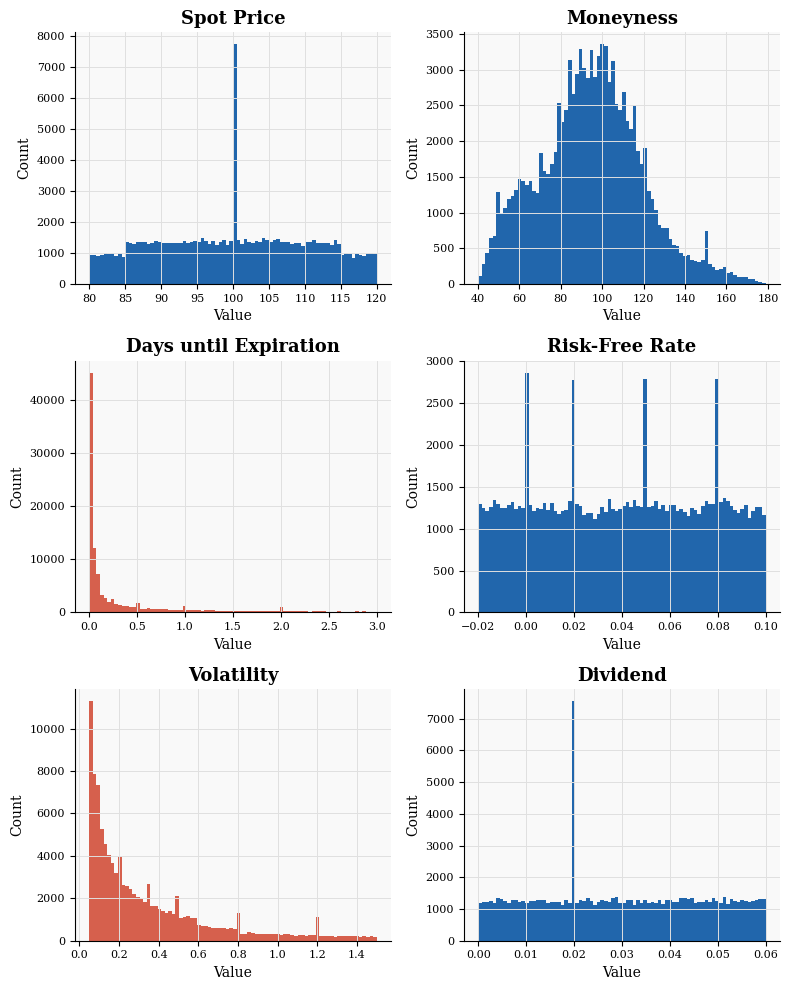

In [106]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))

axes[0][0].hist(df["S"], bins=80, color=blue, edgecolor="none")
axes[0][0].set_title("Spot Price", fontsize=13)
axes[0][0].set_xlabel("Value")
axes[0][0].set_ylabel("Count")

axes[0][1].hist(df["K"], bins=80, color=blue, edgecolor="none")
axes[0][1].set_title("Moneyness", fontsize=13)
axes[0][1].set_xlabel("Value")
axes[0][1].set_ylabel("Count")

axes[1][0].hist(df["T"], bins=80, color=red, edgecolor="none")
axes[1][0].set_title("Days until Expiration", fontsize=13)
axes[1][0].set_xlabel("Value")
axes[1][0].set_ylabel("Count")

axes[1][1].hist(df["r"], bins=80, color=blue, edgecolor="none")
axes[1][1].set_title("Risk-Free Rate", fontsize=13)
axes[1][1].set_xlabel("Value")
axes[1][1].set_ylabel("Count")

axes[2][0].hist(df["sigma"], bins=80, color=red, edgecolor="none")
axes[2][0].set_title("Volatility", fontsize=13)
axes[2][0].set_xlabel("Value")
axes[2][0].set_ylabel("Count")

axes[2][1].hist(df["q"], bins=80, color=blue, edgecolor="none")
axes[2][1].set_title("Dividend", fontsize=13)
axes[2][1].set_xlabel("Value")
axes[2][1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Run Model

In [107]:
spy = pd.read_csv("spy.csv", nrows=10000)


In [108]:
spy.head()

,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],[C_VEGA],[C_THETA],[C_RHO],[C_IV],[C_VOLUME],[C_LAST],[C_SIZE],[C_BID],[C_ASK],[STRIKE],[P_BID],[P_ASK],[P_SIZE],[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005170,,1.000000,182.650000,1 x 1,181.090000,182.310000,270.0,0.000000,0.010000,0 x 2239,0.010000,-0.000240,0.000000,0.000040,-0.005090,0.000000,3.412490,3.000000,181.9,0.402
1,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005270,,,0.000000,1 x 1,176.090000,177.310000,275.0,0.000000,0.010000,0 x 2679,0.010000,-0.000630,0.000030,0.000190,-0.004800,0.000000,3.297370,0.000000,176.9,0.391
2,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005690,,25.000000,157.750000,1 x 1,171.090000,172.310000,280.0,0.000000,0.010000,0 x 2679,0.010000,0.000000,0.000000,-0.000230,-0.005340,0.000000,3.183300,11.000000,171.9,0.380
3,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005300,,25.000000,153.450000,1 x 1,166.140000,167.300000,285.0,0.000000,0.010000,0 x 2679,0.010000,-0.000160,0.000040,0.000380,-0.005320,0.000000,3.072170,50.000000,166.9,0.369
4,1630526400,2021-09-01 16:00,2021-09-01,16.0,451.85,2021-09-01,1630526400,0.0,1.000000,0.000000,0.000000,0.000000,0.005340,,25.000000,147.760000,1 x 1,161.090000,162.310000,290.0,0.000000,0.010000,0 x 2679,0.010000,-0.000680,0.000000,0.000450,-0.005150,0.000000,2.962300,0.000000,161.9,0.358


In [109]:
print(df.columns.tolist())

['S', 'K', 'T', 'r', 'sigma', 'q', 'log_moneyness', 'sqrt_T', 'option_type', 'bs_price', 'bs_delta', 'american_price', 'moneyness', 'intrinsic_value_raw', 'intrinsic_normalized', 'total_variance', 'vol_sqrt_T', 'cost_of_carry', 'EEP', 'norm_price', 'norm_bs_price', 'norm_EEP', 'time_scaled_variance', 'normalized_intrinsic', 'bs_gamma', 'bs_vega', 'bs_theta', 'strike_distance_pct']


In [110]:
if __name__ == "__main__":

    target_column_name = 'norm_EEP'
    
    train_loader, test_loader, input_features, y_scaler, x_scaler, K_test, bs_price, type, q_test = prepare_data(df, target_col=target_column_name)
    
    model = surrogateDNN(input_size=input_features, output_size=1)
    criterion = nn.HuberLoss()
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    EPOCHS = 100
    print(f"Epoch {EPOCHS} ")

    train_losses, val_losses = [], []
    
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0
        all_preds_list = []
        all_targets_list = []
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                out = model(batch_X)
                val_loss += criterion(out, batch_y).item()
                all_preds_list.append(out)
                all_targets_list.append(batch_y)
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        scheduler.step(avg_train_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_train_loss:.6f}, Val: {avg_val_loss:.6f}')


    preds_combined = torch.cat(all_preds_list).numpy()
    targets_combined = torch.cat(all_targets_list).numpy()

    pred_eep = y_scaler.inverse_transform(preds_combined)
    true_eep = y_scaler.inverse_transform(targets_combined)

    pred_eep = np.maximum(pred_eep, 0)

    pred_eep_usd = pred_eep * K_test
    true_eep_usd = true_eep * K_test

    pred_price = bs_price + pred_eep_usd
    true_price = bs_price + true_eep_usd

    merton_mask = (type == 1) & np.isclose(q_test, 0.0)
    pred_price[merton_mask] = bs_price[merton_mask]

    mae= np.mean(np.abs(pred_price - true_price))
    mse= np.mean((pred_price - true_price)**2)
    rmse= np.sqrt(mse)
    max_sq_error = np.max((pred_price - true_price)**2)
    within_penny = np.mean(np.abs(pred_price - true_price) <= 0.05) * 100

    print(f'Mean Absolute Error: ${mae:.4f}')
    print(f'Root Mean Squared Error: ${rmse:.4f}')
    print(f'Max Squared Error: ${max_sq_error:.4f}')
    print(f'Within $0.05 absolute error: {within_penny:.1f}%')

Epoch 100 
Epoch [10/100], Loss: 0.004086, Val: 0.002681
Epoch [20/100], Loss: 0.001906, Val: 0.001808
Epoch [30/100], Loss: 0.000673, Val: 0.000817
Epoch [40/100], Loss: 0.000579, Val: 0.000404
Epoch [50/100], Loss: 0.000382, Val: 0.000377
Epoch [60/100], Loss: 0.000302, Val: 0.000352
Epoch [70/100], Loss: 0.000279, Val: 0.000311
Epoch [80/100], Loss: 0.000281, Val: 0.000312
Epoch [90/100], Loss: 0.000276, Val: 0.000297
Epoch [100/100], Loss: 0.000269, Val: 0.000304
Mean Absolute Error: $0.0096
Root Mean Squared Error: $0.0229
Max Squared Error: $0.1313
Within $0.05 absolute error: 96.2%


Epoch 100 
Epoch [10/100], Loss: 0.008156, Val: 0.008066
Epoch [20/100], Loss: 0.003981, Val: 0.010275
Epoch [30/100], Loss: 0.000505, Val: 0.000695
Epoch [40/100], Loss: 0.000362, Val: 0.000379
Epoch [50/100], Loss: 0.000330, Val: 0.000370
Epoch [60/100], Loss: 0.000309, Val: 0.000336
Epoch [70/100], Loss: 0.000307, Val: 0.000336
Epoch [80/100], Loss: 0.000276, Val: 0.000307
Epoch [90/100], Loss: 0.000275, Val: 0.000315
Epoch [100/100], Loss: 0.000276, Val: 0.000305
Mean Absolute Error: $0.0098
Root Mean Squared Error: $0.0230
Max Squared Error: $0.1050
Within $0.05 absolute error: 96.1%

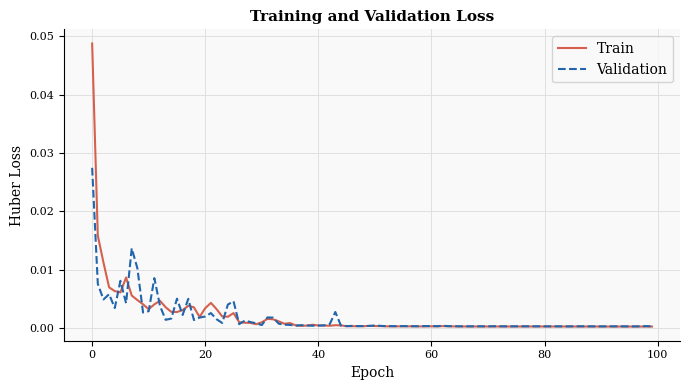

In [111]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, color=red, label="Train")
ax.plot(val_losses, color=blue, linestyle="--", label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

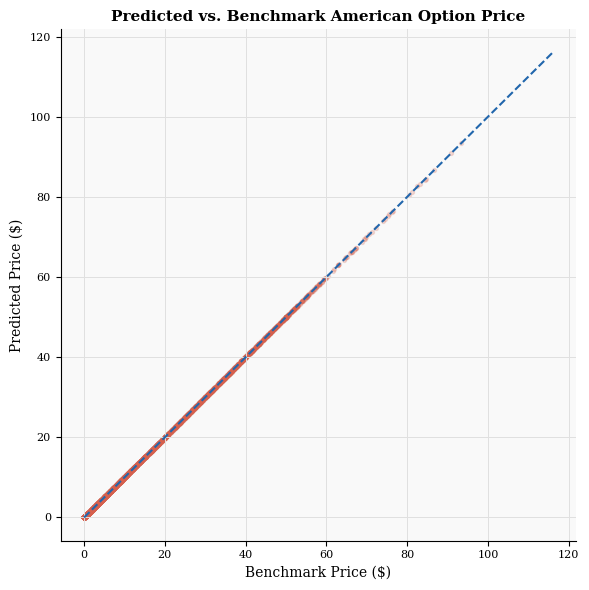

In [112]:
idx = np.random.default_rng(42).choice(len(true_price), 5000, replace=False)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(true_price[idx], pred_price[idx], alpha=0.2, s=8, color=red)
lims = [true_price.min(), true_price.max()]
ax.plot(lims, lims, color=blue, linestyle="--", linewidth=1.5)
ax.set_xlabel("Benchmark Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("Predicted vs. Benchmark American Option Price")
plt.tight_layout()
plt.show()

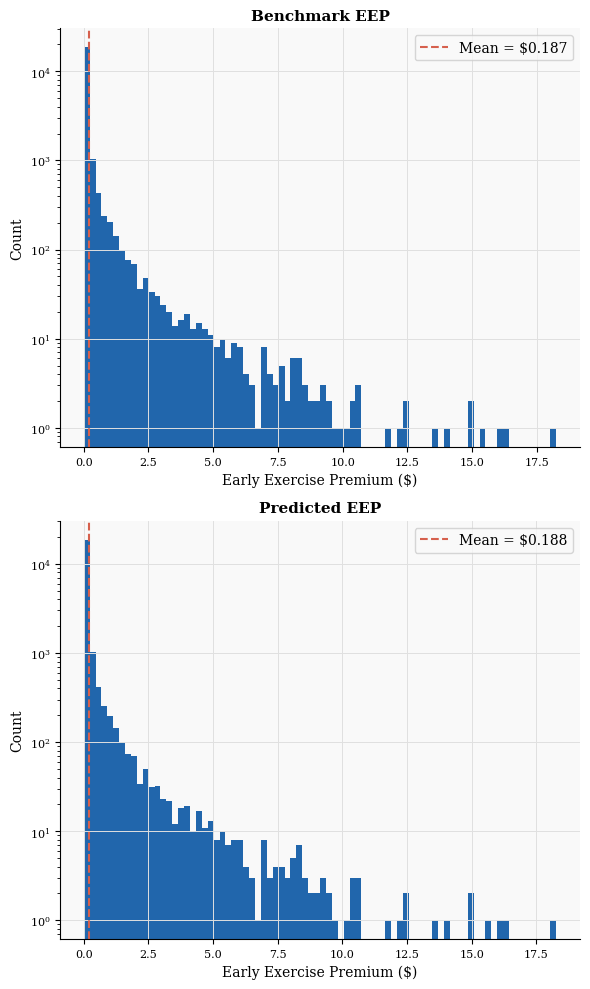

In [113]:
fig, axes = plt.subplots(2,1, figsize=(6, 10))
for ax, data, title in zip(axes,[true_eep_usd.ravel(), pred_eep_usd.ravel()],["Benchmark EEP", "Predicted EEP"]):
    ax.hist(data, bins=80, color=blue)
    ax.axvline(np.mean(data), color=red, linestyle="--",label=f"Mean = ${np.mean(data):.3f}")
    ax.set_xlabel("Early Exercise Premium ($)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.set_yscale("log")
    ax.legend()
plt.tight_layout()
plt.show()

In [115]:
import time

N_TRIALS = 5
drop_cols = ['norm_EEP', 'american_price', 'bs_price', 'EEP', 'norm_price', 'S', 'K', 'intrinsic_value_raw']
feat_cols = [c for c in df.columns if c not in drop_cols]
sample = df.sample(1000, random_state=42)
feats = torch.tensor(x_scaler.transform(sample[feat_cols]), dtype=torch.float32)

ql_times, dnn_times = [], []

for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    ql_prices = sample.apply(
        lambda r: price_american_crr(r['S'], r['K'], r['T'], r['r'], r['sigma'], r['q'], r['option_type']), axis=1
    ).values
    ql_times.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    with torch.no_grad():
        preds = model(feats).numpy()
    dnn_times.append(time.perf_counter() - t0)

ql_avg  = np.mean(ql_times)
dnn_avg = np.mean(dnn_times)

pred_prices = sample['bs_price'].values + np.maximum(
    y_scaler.inverse_transform(preds).ravel() * sample['K'].values, 0
)
mae_sample = np.mean(np.abs(pred_prices - ql_prices))

print(f"QuantLib  : {ql_avg/len(sample)*1000:.3f} ms/contract (avg over {N_TRIALS} runs)")
print(f"DNN       : {dnn_avg/len(sample)*1000:.4f} ms/contract (avg over {N_TRIALS} runs)")
print(f"Speedup   : {ql_avg/dnn_avg:.2f}x")
print(f"MAE vs QL : ${mae_sample:.4f}")

QuantLib  : 2.908 ms/contract (avg over 5 runs)
DNN       : 0.0045 ms/contract (avg over 5 runs)
Speedup   : 644.38x
MAE vs QL : $0.0095


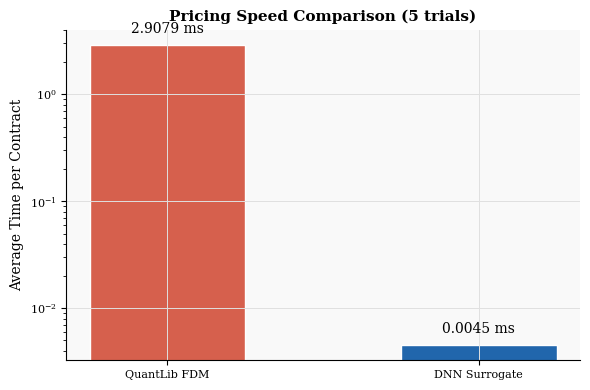

In [116]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["QuantLib FDM", "DNN Surrogate"],
       [ql_avg/len(sample)*1000, dnn_avg/len(sample)*1000],
       color=[red, blue], edgecolor="white", width=0.5)
ax.set_yscale("log")
ax.set_ylabel("Average Time per Contract")
ax.set_title(f"Pricing Speed Comparison (5 trials)")
for i, val in enumerate([ql_avg/len(sample)*1000, dnn_avg/len(sample)*1000]):
    ax.text(i, val * 1.3, f"{val:.4f} ms", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### Clean Spy data so columns match sythetic data

In [117]:
spy = pd.read_csv('spy.csv').sample(n=200000, random_state=42)
spy.columns = spy.columns.str.replace(r'[\[\]]', '', regex=True).str.strip()
spy.head()

/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/516502305.py:1: DtypeWarning: Columns (8,9,10,11,12,13,15,17,18,20,21,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  spy = pd.read_csv('spy.csv').sample(n=200000, random_state=42)


,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,C_VEGA,C_THETA,C_RHO,C_IV,C_VOLUME,C_LAST,C_SIZE,C_BID,C_ASK,STRIKE,P_BID,P_ASK,P_SIZE,P_LAST,P_DELTA,P_GAMMA,P_VEGA,P_THETA,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE,STRIKE_DISTANCE_PCT
3038170,1637096400,2021-11-16 16:00,2021-11-16,16.0,469.17,2023-01-20,1674248400,430.0,0.012820,0.000390,0.175010,-0.002920,0.069080,0.162570,61.000000,0.260000,1 x 1,0.200000,0.520000,700.0,231.660000,235.510000,272 x 330,0.000000,-0.993730,0.000000,0.000000,-0.006380,-8.249340,0.000120,,230.8,0.492
3387550,1614632400,2021-03-01 16:00,2021-03-01,16.0,389.52,2021-03-01,1614632400,0.0,1.0,0.0,0.0,-0.00029,0.00787,,,0.0,200 x 200,93.74,94.47,295.0,0.0,0.01,0 x 3943,0.01,-0.00032,0.00006,0.00041,-0.00528,-0.00042,1.649160,0.000000,94.5,0.243
2267486,1644267600,2022-02-07 16:00,2022-02-07,16.0,447.24,2022-02-22,1645563600,15.0,0.01357,0.00265,0.03326,-0.01372,0.00284,0.144780,65.000000,0.06,152 x 739,0.06,0.07,478.0,30.6,31.08,25 x 25,31.24,-0.94603,0.00182,0.0948,-0.05207,-0.06193,0.176000,0.000000,30.8,0.069
2864270,1627675200,2021-07-30 16:00,2021-07-30,16.0,438.50,2021-09-30,1633032000,62.0,0.87776,0.0041,0.35987,-0.06817,0.38023,0.255410,1.000000,40.9,50 x 50,51.75,52.08,389.0,2.87,2.9,268 x 538,2.75,-0.12048,0.0043,0.36523,-0.07523,-0.09513,0.255210,26.000000,49.5,0.113
1312443,1607634000,2020-12-10 16:00,2020-12-10,16.0,366.77,2021-01-13,1610571600,34.0,0.03621,0.00488,0.09212,-0.01703,0.01279,0.144520,,0.0,2716 x 246,0.22,0.25,396.0,30.46,31.01,23 x 16,0.0,-1.0,0.0,-302.30002,0.0,0.0,0.000660,,29.2,0.080


## synthetic rows
S | K | T | r | sigma | q | log_moneyness | sqrt_T | option_type

In [118]:
calls = spy[['C_BID', #bid
             'C_ASK', #ask
             'QUOTE_DATE',
            'EXPIRE_DATE', #expiration
            'C_IV', #sigma
            'STRIKE',
            'UNDERLYING_LAST']] #strike
puts = spy[['P_BID', #bid
             'P_ASK', #ask
             'QUOTE_DATE',
            'EXPIRE_DATE', #expiration
            'P_IV', #sigma
            'STRIKE',
            'UNDERLYING_LAST']] #strike
calls.dropna(inplace=True)
puts.dropna(inplace=True)
calls.head()

/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/328307881.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls.dropna(inplace=True)
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/328307881.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts.dropna(inplace=True)


,C_BID,C_ASK,QUOTE_DATE,EXPIRE_DATE,C_IV,STRIKE,UNDERLYING_LAST
3038170,0.200000,0.520000,2021-11-16,2023-01-20,0.162570,700.0,469.17
3387550,93.74,94.47,2021-03-01,2021-03-01,,295.0,389.52
2267486,0.06,0.07,2022-02-07,2022-02-22,0.144780,478.0,447.24
2864270,51.75,52.08,2021-07-30,2021-09-30,0.255410,389.0,438.50
1312443,0.22,0.25,2020-12-10,2021-01-13,0.144520,396.0,366.77


In [119]:
print(calls["C_ASK"].dtype)
calls["C_ASK"] = pd.to_numeric(calls["C_ASK"], errors='coerce').fillna(0)
calls["C_BID"] = pd.to_numeric(calls["C_BID"], errors='coerce').fillna(0)
calls["C_IV"] = pd.to_numeric(calls["C_IV"], errors='coerce').fillna(0)

puts["P_ASK"] = pd.to_numeric(puts["P_ASK"], errors='coerce').fillna(0)
puts["P_BID"] = pd.to_numeric(puts["P_BID"], errors='coerce').fillna(0)
puts["P_IV"] = pd.to_numeric(puts["P_IV"], errors='coerce').fillna(0)

print(calls["C_ASK"].dtype)


/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls["C_ASK"] = pd.to_numeric(calls["C_ASK"], errors='coerce').fillna(0)
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls["C_BID"] = pd.to_numeric(calls["C_BID"], errors='coerce').fillna(0)
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:4: SettingWithCopyWarning: 
A va

object
float64


/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts["P_ASK"] = pd.to_numeric(puts["P_ASK"], errors='coerce').fillna(0)
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts["P_BID"] = pd.to_numeric(puts["P_BID"], errors='coerce').fillna(0)
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/834330673.py:8: SettingWithCopyWarning: 
A value 

In [120]:
calls["american_price"] = (calls["C_ASK"] + calls["C_BID"]) / 2
puts["american_price"] = (puts["P_ASK"] + puts["P_BID"])/2
calls.drop(columns=["C_ASK", "C_BID"], inplace=True)
puts.drop(columns=["P_ASK", "P_BID"], inplace=True)

calls.head()

/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/638539262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  calls["american_price"] = (calls["C_ASK"] + calls["C_BID"]) / 2
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/638539262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts["american_price"] = (puts["P_ASK"] + puts["P_BID"])/2
/var/folders/3w/x6h1lx4d59s8gclgknfmyhnr0000gn/T/ipykernel_93521/638539262.py:3: SettingWithCopyWarning: 
A value is trying to be set o

,QUOTE_DATE,EXPIRE_DATE,C_IV,STRIKE,UNDERLYING_LAST,american_price
3038170,2021-11-16,2023-01-20,0.16257,700.0,469.17,0.360
3387550,2021-03-01,2021-03-01,0.00000,295.0,389.52,94.105
2267486,2022-02-07,2022-02-22,0.14478,478.0,447.24,0.065
2864270,2021-07-30,2021-09-30,0.25541,389.0,438.50,51.915
1312443,2020-12-10,2021-01-13,0.14452,396.0,366.77,0.235


In [121]:
calls.describe()

,C_IV,STRIKE,UNDERLYING_LAST,american_price
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.323496,367.930045,386.862039,49.598022
std,0.463470,109.382187,55.937929,63.803324
min,-0.000500,5.000000,222.210000,0.000000
25%,0.171320,300.000000,342.890000,1.975000
50%,0.233480,369.000000,393.480000,24.200000
75%,0.333760,436.000000,434.160000,73.060000
max,31.603710,4898.000000,477.770000,438.130000


S | K | T | r | sigma | q | log_moneyness | sqrt_T | option_type

## Split and Restack
Sicne the calls and puts are currently inline we split rename then stack them to match the synthetic dataset.

In [158]:
calls.rename(columns={'C_IV':'sigma',
                        'STRIKE': 'K',
                        'UNDERLYING_LAST': 'S'} , inplace=True)
calls['option_type'] = 1

puts.rename(columns={'P_IV':'sigma',
                        'STRIKE': 'K',
                        'UNDERLYING_LAST': 'S'} , inplace=True)
puts['option_type'] = 0

spy = pd.concat([calls, puts], ignore_index=False)

spy['log_moneyness'] = np.log(spy['S'] / spy['K'])
spy['T'] = (pd.to_datetime(spy['EXPIRE_DATE']) - pd.to_datetime(spy['QUOTE_DATE'])).dt.days / 365
spy['sqrt_T'] = np.sqrt(spy['T'])
spy.describe()


,sigma,K,S,american_price,option_type,log_moneyness,T,sqrt_T
count,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000
mean,0.318595,367.930045,386.862039,40.354208,0.500000,0.090009,0.427437,0.530634
std,0.393573,109.382051,55.937859,57.398288,0.500001,0.311336,0.555695,0.381923
min,-0.000500,5.000000,222.210000,0.000000,0.000000,-2.424368,0.000000,0.000000
25%,0.174770,300.000000,342.890000,1.675000,0.000000,-0.076406,0.052055,0.228155
50%,0.244230,369.000000,393.480000,16.410000,0.500000,0.033169,0.178082,0.421998
75%,0.351322,436.000000,434.160000,53.865000,1.000000,0.194369,0.605479,0.778126
max,31.603710,4898.000000,477.770000,438.130000,1.000000,4.270480,3.002740,1.732842


In [159]:
spy.head()

,QUOTE_DATE,EXPIRE_DATE,sigma,K,S,american_price,option_type,log_moneyness,T,sqrt_T
3038170,2021-11-16,2023-01-20,0.16257,700.0,469.17,0.360,1,-0.400115,1.178082,1.085395
3387550,2021-03-01,2021-03-01,0.00000,295.0,389.52,94.105,1,0.277940,0.000000,0.000000
2267486,2022-02-07,2022-02-22,0.14478,478.0,447.24,0.065,1,-0.066515,0.041096,0.202721
2864270,2021-07-30,2021-09-30,0.25541,389.0,438.50,51.915,1,0.119780,0.169863,0.412144
1312443,2020-12-10,2021-01-13,0.14452,396.0,366.77,0.235,1,-0.076679,0.093151,0.305206


## Pull Risk-Free Rate from Fred public database for 2020-2022

In [160]:
import pandas as pd
import pandas_datareader as pdr

tbill = pdr.get_data_fred('DGS3MO', start='2019-01-01', end='2022-12-31')
tbill['r'] = tbill['DGS3MO'] / 100 
tbill.index = pd.to_datetime(tbill.index)

#cover holidays
tbill['r'] = tbill['r'].ffill()

spy['QUOTE_DATE'] = pd.to_datetime(spy['QUOTE_DATE'])
spyR = spy.merge(tbill[['r']], left_on='QUOTE_DATE', right_index=True, how='left')
spyR['r'] = spyR['r'].ffill().bfill()

In [161]:
spyR.describe()

,QUOTE_DATE,sigma,K,S,american_price,option_type,log_moneyness,T,sqrt_T,r
count,400000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000,400000.000000
mean,2021-07-01 00:41:08.015999488,0.318595,367.930045,386.862039,40.354208,0.500000,0.090009,0.427437,0.530634,0.007663
min,2020-01-02 00:00:00,-0.000500,5.000000,222.210000,0.000000,0.000000,-2.424368,0.000000,0.000000,0.000000
25%,2020-10-09 00:00:00,0.174770,300.000000,342.890000,1.675000,0.000000,-0.076406,0.052055,0.228155,0.000500
50%,2021-07-07 00:00:00,0.244230,369.000000,393.480000,16.410000,0.500000,0.033169,0.178082,0.421998,0.001100
75%,2022-03-16 00:00:00,0.351322,436.000000,434.160000,53.865000,1.000000,0.194369,0.605479,0.778126,0.009000
max,2022-12-30 00:00:00,31.603710,4898.000000,477.770000,438.130000,1.000000,4.270480,3.002740,1.732842,0.044600
std,NaN,0.393573,109.382051,55.937859,57.398288,0.500001,0.311336,0.555695,0.381923,0.012489


In [164]:
import numpy as np
import pandas as pd

calls_df = spyR[spyR['option_type'] == 1][['QUOTE_DATE', 'T', 'K', 'S', 'r', 'american_price']]
puts_df = spyR[spyR['option_type'] == 0][['QUOTE_DATE', 'T', 'K', 'american_price']]

# Step B: Merge to find matched pairs (Same Date, Same Expiration, Same Strike)
pairs = pd.merge(
    calls_df, puts_df, 
    on=['QUOTE_DATE', 'T', 'K'], 
    suffixes=('_call', '_put')
)

# Step C: Find the At-The-Money (ATM) pair for every single expiration chain
pairs['moneyness_dist'] = np.abs((pairs['S'] / pairs['K']) - 1.0)
atm_pairs = pairs.loc[pairs.groupby(['QUOTE_DATE', 'T'])['moneyness_dist'].idxmin()].copy()

# Step D: Calculate Implied Dividend Yield (q) using Put-Call Parity
# Formula: q = -(1/T) * ln( (C - P + K * e^(-rT)) / S )
C = atm_pairs['american_price_call']
P = atm_pairs['american_price_put']
S = atm_pairs['S']
K = atm_pairs['K']
r = atm_pairs['r']
T = atm_pairs['T']

# Calculate the inner fraction
inner_term = np.maximum((C - P + K * np.exp(-r * T)) / S, 1e-6) 

# Calculate the implied q and clip extreme outliers
atm_pairs['q_implied'] = - (1 / T) * np.log(inner_term)
atm_pairs['q_implied'] = atm_pairs['q_implied'].clip(lower=-0.05, upper=0.10)

# Step E: Broadcast this perfect Implied q back into the main SPY dataset
spyRD = pd.merge(
    spyR, 
    atm_pairs[['QUOTE_DATE', 'T', 'q_implied']], 
    on=['QUOTE_DATE', 'T'], 
    how='left'
)

spyRD = spyRD.rename(columns={'q_implied': 'q'})
spyRD['q'] = spyRD.groupby('QUOTE_DATE')['q'].transform(lambda x: x.ffill().bfill())
spyRD['q'] = spyRD['q'].fillna(0.015)

In [165]:
'''import yfinance as yf

ticker = yf.Ticker("SPY")
dividends = ticker.dividends
dividends.index = dividends.index.tz_localize(None)

annual_div = dividends.rolling(4).sum()
annual_div = annual_div.reset_index().rename(columns={'Date': 'QUOTE_DATE', 'Dividends': 'annual_dividend'})

spyRD = pd.merge_asof(
    spyR.sort_values('QUOTE_DATE'),
    annual_div.sort_values('QUOTE_DATE'),
    on='QUOTE_DATE',
    direction='backward'
)

spyRD['q'] = spyRD['annual_dividend'] / spyRD['S']

# convert to yield
spyRD['q'] = spyRD['annual_dividend'] / spyRD['S']
spyRD.drop(columns=['annual_dividend'], inplace=True)'''



'import yfinance as yf\n\nticker = yf.Ticker("SPY")\ndividends = ticker.dividends\ndividends.index = dividends.index.tz_localize(None)\n\nannual_div = dividends.rolling(4).sum()\nannual_div = annual_div.reset_index().rename(columns={\'Date\': \'QUOTE_DATE\', \'Dividends\': \'annual_dividend\'})\n\nspyRD = pd.merge_asof(\n    spyR.sort_values(\'QUOTE_DATE\'),\n    annual_div.sort_values(\'QUOTE_DATE\'),\n    on=\'QUOTE_DATE\',\n    direction=\'backward\'\n)\n\nspyRD[\'q\'] = spyRD[\'annual_dividend\'] / spyRD[\'S\']\n\n# convert to yield\nspyRD[\'q\'] = spyRD[\'annual_dividend\'] / spyRD[\'S\']\nspyRD.drop(columns=[\'annual_dividend\'], inplace=True)'

In [166]:

spyRD.drop(columns=['QUOTE_DATE','EXPIRE_DATE'], inplace= True)
spy_clean =spyRD

In [167]:
spy_clean.head()

,sigma,K,S,american_price,option_type,log_moneyness,T,sqrt_T,r,q
0,0.16257,700.0,469.17,0.360,1,-0.400115,1.178082,1.085395,0.0005,0.005551
1,0.00000,295.0,389.52,94.105,1,0.277940,0.000000,0.000000,0.0005,0.100000
2,0.14478,478.0,447.24,0.065,1,-0.066515,0.041096,0.202721,0.0027,0.005299
3,0.25541,389.0,438.50,51.915,1,0.119780,0.169863,0.412144,0.0006,0.014513
4,0.14452,396.0,366.77,0.235,1,-0.076679,0.093151,0.305206,0.0008,0.033344


In [168]:
df.head()

,S,K,T,r,sigma,q,log_moneyness,sqrt_T,option_type,bs_price,bs_delta,american_price,moneyness,intrinsic_value_raw,intrinsic_normalized,total_variance,vol_sqrt_T,cost_of_carry,EEP,norm_price,norm_bs_price,norm_EEP,time_scaled_variance,normalized_intrinsic,bs_gamma,bs_vega,bs_theta,strike_distance_pct
0,94.981605,138.154645,0.008803,0.036158,0.057020,0.037219,-0.374690,0.093822,1,0.000000,0.000000,0.000000,0.687502,0.000000,0.000000,0.000029,0.005350,-0.001061,0.000000,0.000000,0.000000,0.000000,0.000029,0.000000,0.000000e+00,0.000000e+00,0.000000,0.454541
1,118.028572,69.000309,0.005482,-0.002185,0.072419,0.002106,0.536816,0.074038,1,49.026075,0.999988,49.028264,1.710551,49.028264,0.710551,0.000029,0.005362,-0.004290,0.002189,0.710551,0.710520,0.000032,0.000029,0.710551,0.000000e+00,0.000000e+00,0.001094,-0.415393
2,109.279758,145.460445,0.548624,0.056553,0.217681,0.003544,-0.285993,0.740692,1,0.470891,0.065040,0.475868,0.751268,0.000000,0.000000,0.025996,0.161234,0.053009,0.004977,0.003271,0.003237,0.000034,0.025996,0.000000,7.196515e-03,1.026352e-01,-0.006538,0.331083
3,103.946339,74.578482,0.026670,0.080711,1.249259,0.024876,0.332023,0.163310,1,29.841740,0.958148,29.871184,1.393785,29.367857,0.393785,0.041623,0.204016,0.055834,0.029445,0.400534,0.400139,0.000395,0.041623,0.393785,4.160768e-03,1.497849e-02,-0.104748,-0.282529
4,86.240746,43.724145,1.371807,0.003343,0.064503,0.041627,0.679242,1.171242,1,37.929901,0.944495,42.516601,1.972383,42.516601,0.972383,0.005708,0.075549,-0.038284,4.586700,0.972383,0.867482,0.104901,0.005708,0.972383,4.810629e-17,3.165917e-16,0.008891,-0.492999


## New method to get eep since it is off of price and not American price

## Generate engineered columns using methods

In [169]:
print("Generating parameter")
spy_df = add_black_scholes_features(spy_clean)

print("Prepare dataset with computed columns")
spy_df = prepare_dnn_dataset(spy_df)
spy_df = spy_df.dropna(subset=['bs_gamma', 'bs_theta'])
spy_df = spy_df[spy_df['T'] > 0]
spy_df.head()

Generating parameter
Prepare dataset with computed columns


,sigma,K,S,american_price,option_type,log_moneyness,T,sqrt_T,r,q,bs_price,bs_delta,moneyness,intrinsic_value_raw,intrinsic_normalized,total_variance,vol_sqrt_T,cost_of_carry,EEP,norm_price,norm_bs_price,norm_EEP,time_scaled_variance,normalized_intrinsic,bs_gamma,bs_vega,bs_theta,strike_distance_pct
0,0.16257,700.0,469.17,0.360,1,-0.400115,1.178082,1.085395,0.0005,0.005551,0.366408,0.013360,0.670243,0.00,0.000000,0.031136,0.176453,-0.005051,-0.006408,0.000514,0.000523,-9.154394e-06,0.031136,0.000000,0.000414,0.174378,-0.003209,0.491997
2,0.14478,478.0,447.24,0.065,1,-0.066515,0.041096,0.202721,0.0027,0.005299,0.054231,0.012056,0.935649,0.00,0.000000,0.000861,0.029350,-0.002599,0.010769,0.000136,0.000113,2.253006e-05,0.000861,0.000000,0.002389,0.028432,-0.013683,0.068777
3,0.25541,389.0,438.50,51.915,1,0.119780,0.169863,0.412144,0.0006,0.014513,51.347026,0.876447,1.127249,49.50,0.127249,0.011081,0.105266,-0.013913,0.567974,0.133458,0.131997,1.460088e-03,0.011081,0.127249,0.004358,0.363568,-0.060153,-0.112885
4,0.14452,396.0,366.77,0.235,1,-0.076679,0.093151,0.305206,0.0008,0.033344,0.235264,0.037007,0.926187,0.00,0.000000,0.001946,0.044108,-0.032544,-0.000264,0.000593,0.000594,-6.670647e-07,0.001946,0.000000,0.004997,0.090487,-0.018021,0.079696
5,0.28780,306.0,354.07,53.450,1,0.145910,0.353425,0.594495,0.0010,0.014282,52.836378,0.814705,1.157092,48.07,0.157092,0.029274,0.171096,-0.013282,0.613622,0.174673,0.172668,2.005302e-03,0.029274,0.157092,0.004327,0.551794,-0.050911,-0.135764


In [170]:
spy_df['bs_price'] = np.maximum(spy_df['bs_price'], spy_df['intrinsic_value_raw'])
spy_df = spy_df[(spy_df['moneyness'] > 0.5) & (spy_df['moneyness'] < 1.5)]

In [ ]:
cols_to_drop = ['american_price', 'bs_price', 'EEP', 'norm_price', 'norm_EEP']
X_spy = spy_df.drop(columns=[c for c in cols_to_drop if c in spy_df.columns])

K_spy = spy_df['K'].values.reshape(-1, 1)
bs_price_spy = spy_df['bs_price'].values.reshape(-1, 1)
type_spy = spy_df['option_type'].values.reshape(-1, 1)
q_spy = spy_df['q'].values.reshape(-1, 1)

# reorder columns to match training
X_spy = X_spy[x_scaler.feature_names_in_]

# scale using the TRAINING scaler, not fit a new one
X_spy_scaled = x_scaler.transform(X_spy)
X_spy_tensor = torch.tensor(X_spy_scaled, dtype=torch.float32)

# inference
model.eval()
with torch.no_grad():
    preds_scaled = model(X_spy_tensor).numpy()

# inverse transform and reconstruct price
pred_eep = y_scaler.inverse_transform(preds_scaled)
pred_eep = np.maximum(pred_eep, 0)
pred_eep_usd = pred_eep * K_spy
pred_price = bs_price_spy + pred_eep_usd

# apply merton's rule
merton_mask = (type_spy == 1) & np.isclose(q_spy, 0.0)
pred_price[merton_mask] = bs_price_spy[merton_mask]

# compare against actual market prices
true_price = spy_df['american_price'].values.reshape(-1, 1)

mae = np.mean(np.abs(pred_price - true_price))
rmse = np.sqrt(np.mean((pred_price - true_price)**2))
within_penny = np.mean(np.abs(pred_price - true_price) <= 0.05) * 100

print(f'MAE: ${mae:.4f}')
print(f'RMSE: ${rmse:.4f}')
print(f'Within $0.05: {within_penny:.1f}%')

MAE: $0.4146
RMSE: $1.5043
Within $0.05: 34.9%
